<a href="https://colab.research.google.com/github/Kryptera-K/CCL-Adaptive-Volatility-Reversion-Strategy-KC-MACD-/blob/main/CCL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install vectorbt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.8/527.8 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.5/315.5 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 33.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import vectorbt as vbt

# -------------------------
# Download Data
# -------------------------

symbol = "CCL"
start_date = "2000-01-01"
end_date = "2026-01-01"
interval = "1d"

df = yf.download(symbol, start=start_date, end=end_date, interval=interval, multi_level_index=False)
df.to_csv("CCL_clean.csv", index=False)
df

/tmp/ipython-input-3334730487.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=end_date, interval=interval, multi_level_index=False)
[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2000-01-03,28.774670,28.928135,27.777148,28.237542,1532600
2000-01-04,28.429359,29.196684,28.352627,29.158317,1061600
2000-01-05,29.388512,29.810540,28.429357,28.429357,1674400
2000-01-06,29.810549,30.270943,28.928126,29.350154,1437300
2000-01-07,29.465240,29.810536,28.851381,28.851381,1813900
...,...,...,...,...,...
2025-12-24,31.250000,31.620001,31.120001,31.480000,7559200
2025-12-26,30.700001,31.450001,30.610001,31.250000,10287000
2025-12-29,30.719999,30.719999,30.270000,30.440001,14914700


In [ ]:
# -------------------------
# Necessary Parameters
# -------------------------

KC_MULTIPLIER = 2
KC_PERIOD = 20
KC_SHIFT = 5
MACD_FAST = 12
MACD_SIGNAL = 9
MACD_SLOW = 26

# -------------------------
# Indicator Functions
# -------------------------

def kc_open_above_lower_after_below(df, shift=KC_SHIFT):
    df = calculate_keltner_channel(df)
    return df['Open'].gt(df['KC_Lower']) & df['Open'].shift(shift).lt(df['KC_Lower'])


def calculate_keltner_channel(df, period=KC_PERIOD, multiplier=KC_MULTIPLIER):
    """
    Calculate Keltner Channel (Mid, Upper, Lower) and ATR.
    """
    df = df.copy()

    # Typical Price
    df['TP'] = (df['High'] + df['Low'] + df['Close']) / 3

    # EMA of Typical Price
    df['KC_Mid'] = df['TP'].ewm(span=period, adjust=False).mean()

    # True Range and ATR
    df['H-L'] = df['High'] - df['Low']
    df['H-PC'] = abs(df['High'] - df['Close'].shift(1))
    df['L-PC'] = abs(df['Low'] - df['Close'].shift(1))
    df['TR'] = df[['H-L','H-PC','L-PC']].max(axis=1)
    df['ATR'] = df['TR'].rolling(period).mean()

    # Upper and Lower Bands
    df['KC_Upper'] = df['KC_Mid'] + multiplier * df['ATR']
    df['KC_Lower'] = df['KC_Mid'] - multiplier * df['ATR']

    return df


def macd_cross_below_signal(df):
    df = calculate_macd(df)
    return (df["MACD_prev"] >= df["Signal_prev"]) & (df["MACD"] < df["Signal"])


def calculate_macd(df, fast=MACD_FAST, slow=MACD_SLOW, signal=MACD_SIGNAL):
    """
    Calculate MACD and Signal lines.
    """
    df = df.copy()
    df["EMA_fast"] = df["Close"].ewm(span=fast, adjust=False).mean()
    df["EMA_slow"] = df["Close"].ewm(span=slow, adjust=False).mean()
    df["MACD"] = df["EMA_fast"] - df["EMA_slow"]
    df["Signal"] = df["MACD"].ewm(span=signal, adjust=False).mean()

    # Previous values for comparisons
    df["MACD_prev"] = df["MACD"].shift(1)
    df["Signal_prev"] = df["Signal"].shift(1)

    return df



# -------------------------
# Entry conditions
# -------------------------

df["KC_Open_Above_Lower_After_Below"] = kc_open_above_lower_after_below(df)

# -------------------------
# Exit conditions
# -------------------------

df["MACD_cross_below_signal"] = macd_cross_below_signal(df)

# -------------------------
# Signals
# -------------------------

entry_conditions = [
    'KC_Open_Above_Lower_After_Below',
]
exit_conditions = [
    'MACD_cross_below_signal',
]

df['entry_signal'] = df[entry_conditions].all(axis=1)
df['exit_signal']  = df[exit_conditions].all(axis=1)

# -------------------------
# Backtest
# -------------------------


shift_entries = df['entry_signal'].shift(1).astype(bool).fillna(False).to_numpy()
shift_exits = df['exit_signal'].shift(1).astype(bool).fillna(False).to_numpy()

pf = vbt.Portfolio.from_signals(
    close=df['Open'],
    entries=shift_entries,
    exits=shift_exits,
    init_cash=100_000,
    fees=0.001,
    slippage=0.002,
    freq='1d'
)


# -------------------------
# Portfolio Stats / Plot
# -------------------------

print(pf.stats())
pf.plot().show()

Start                         2000-01-03 00:00:00
End                           2025-12-31 00:00:00
Period                         6539 days 00:00:00
Start Value                              100000.0
End Value                           424266.406047
Total Return [%]                       324.266406
Benchmark Return [%]                     9.145474
Max Gross Exposure [%]                      100.0
Total Fees Paid                      17793.022829
Max Drawdown [%]                        54.925106
Max Drawdown Duration          3315 days 00:00:00
Total Trades                                   58
Total Closed Trades                            58
Total Open Trades                               0
Open Trade PnL                                0.0
Win Rate [%]                            48.275862
Best Trade [%]                          60.076898
Worst Trade [%]                        -23.341933
Avg Winning Trade [%]                   13.440256
Avg Losing Trade [%]                    -5.942762


In [ ]:
# Buy and Hold Performance Metrics
df_holding = df['Open']
pf_holding = vbt.Portfolio.from_holding(df_holding, init_cash=100_000 , freq='D')
print(pf_holding.stats())

Start                         2000-01-03 00:00:00
End                           2025-12-31 00:00:00
Period                         6539 days 00:00:00
Start Value                              100000.0
End Value                           109145.474384
Total Return [%]                         9.145474
Benchmark Return [%]                     9.145474
Max Gross Exposure [%]                      100.0
Total Fees Paid                               0.0
Max Drawdown [%]                         90.30334
Max Drawdown Duration          2514 days 00:00:00
Total Trades                                    1
Total Closed Trades                             0
Total Open Trades                               1
Open Trade PnL                        9145.474384
Win Rate [%]                                  NaN
Best Trade [%]                                NaN
Worst Trade [%]                               NaN
Avg Winning Trade [%]                         NaN
Avg Losing Trade [%]                          NaN


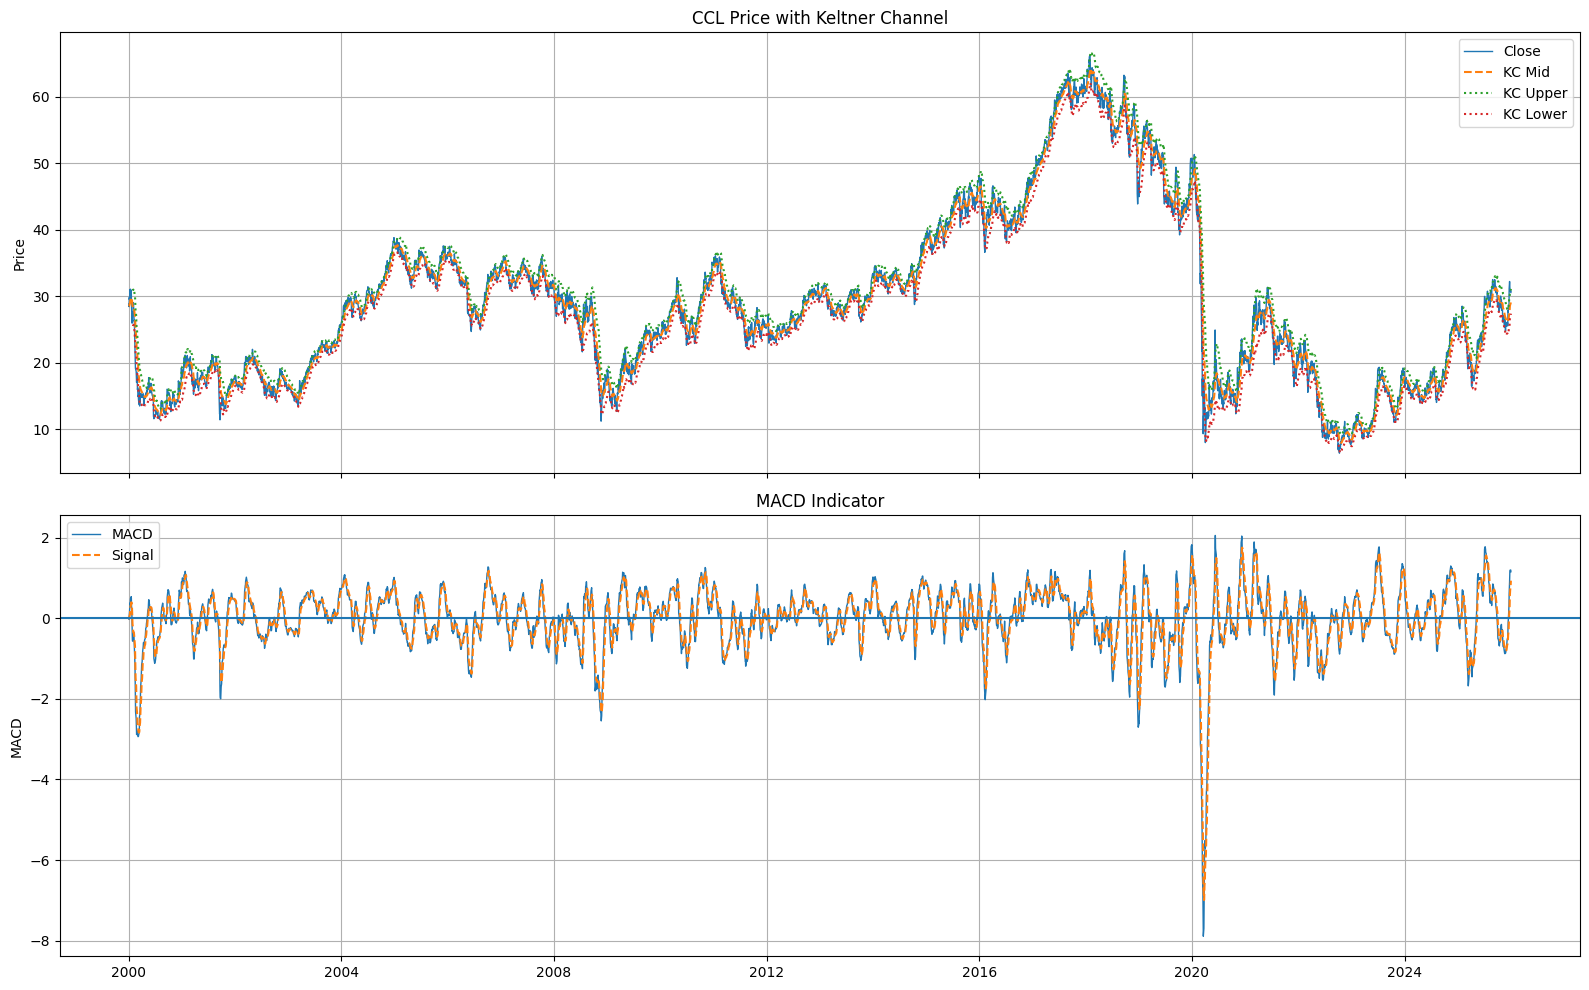

In [ ]:
import matplotlib.pyplot as plt

# -------------------------
# Calculate Indicators
# -------------------------

df_ind = calculate_keltner_channel(df)
df_ind = calculate_macd(df_ind)

# -------------------------
# Plot
# -------------------------

fig, (ax_price, ax_macd) = plt.subplots(
    2, 1, figsize=(16, 10), sharex=True
)

# ===== PRICE + KELTNER CHANNEL =====
ax_price.plot(df_ind.index, df_ind["Close"], label="Close", linewidth=1)
ax_price.plot(df_ind.index, df_ind["KC_Mid"], label="KC Mid", linestyle="--")
ax_price.plot(df_ind.index, df_ind["KC_Upper"], label="KC Upper", linestyle=":")
ax_price.plot(df_ind.index, df_ind["KC_Lower"], label="KC Lower", linestyle=":")

ax_price.set_title("CCL Price with Keltner Channel")
ax_price.set_ylabel("Price")
ax_price.legend()
ax_price.grid(True)

# ===== MACD =====
ax_macd.plot(df_ind.index, df_ind["MACD"], label="MACD", linewidth=1)
ax_macd.plot(df_ind.index, df_ind["Signal"], label="Signal", linestyle="--")

ax_macd.axhline(0)
ax_macd.set_title("MACD Indicator")
ax_macd.set_ylabel("MACD")
ax_macd.legend()
ax_macd.grid(True)

plt.tight_layout()
plt.show()
